# RAPIDS cuML
## Performance, Boundaries, and Correctness Benchmarks

**Description:** This notebook provides a simple and unified means of benchmarking single GPU cuML algorithms against their skLearn counterparts with the `cuml.benchmark` package in RAPIDS cuML. This enables quick and simple measurements of performance, validation of correctness, and investigation of upper bounds.

Each benchmark returns a Pandas `DataFrame` with the results. At the end of the notebook, these results are used to draw charts and output to a CSV file.

Please refer to the [table of contents](#table_of_contents) for algorithms available to be benchmarked with this notebook.

In [1]:
#check GPU
!nvidia-smi

Mon May 18 03:44:21 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   31C    P0             51W /  400W |       0MiB /  81920MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
import cuml
import pandas as pd

from cuml.benchmark.runners import SpeedupComparisonRunner
from cuml.benchmark.algorithms import algorithm_by_name

import warnings
warnings.filterwarnings('ignore', 'Expected column ')

print(cuml.__version__)

26.02.000


In [3]:
N_REPS = 1  # Number of times each test is repeated

DATA_NEIGHBORHOODS = "blobs"
DATA_CLASSIFICATION = "classification"
DATA_REGRESSION = "regression"

INPUT_TYPE = "numpy"

benchmark_results = []

In [4]:
SMALL_ROW_SIZES = [2**x for x in range(14, 17)]
LARGE_ROW_SIZES = [2**x for x in range(18, 24, 2)]

SKINNY_FEATURES = [32]#, 256]
WIDE_FEATURES = [1000, 10000]

VERBOSE=True
RUN_CPU=True

In [5]:
def enrich_result(algorithm, runner, result):
    result["algo"] = algorithm
    result["dataset_name"] = runner.dataset_name
    result["input_type"] = runner.input_type
    return result

def execute_benchmark(algorithm, runner, verbose=VERBOSE, run_cpu=RUN_CPU, **kwargs):
    results = runner.run(algorithm_by_name(algorithm), verbose=verbose, run_cpu=run_cpu, **kwargs)
    results = [enrich_result(algorithm, runner, result) for result in results]
    benchmark_results.extend(results)

## Table of Contents<a id="table_of_contents"/>

### Benchmarks
1. [Neighbors](#neighbors)<br>
    1.1 [Nearest Neighbors - Brute Force](#nn_bruteforce)<br>
    1.2 [KNeighborsClassifier](#kneighborsclassifier)<br>
    1.3 [KNeighborsRegressor](#kneighborsregressor)<br>
2. [Clustering](#clustering)<br>
    2.1 [DBSCAN - Brute Force](#dbscan_bruteforce)<br>
    2.2 [K-Means](#kmeans)<br>
3. [Manifold Learning](#manifold_learning)<br>
    3.1 [UMAP - Unsupervised](#umap_unsupervised)<br>
    3.2 [UMAP - Supervised](#umap_supervised)<br>
    3.3 [T-SNE](#tsne)<br>
4. [Linear Models](#linear_models)<br>
    4.1 [Linear Regression](#linear_regression)<br>
    4.2 [Logistic Regression](#logistic_regression)<br>
    4.3 [Ridge Regression](#ridge_regression)<br>
    4.4 [Lasso Regression](#lasso_regression)<br>
    4.5 [ElasticNet Regression](#elasticnet_regression)<br>
    4.6 [Mini-batch SGD Classifier](#minibatch_sgd_classifier)<br>
5. [Decomposition](#decomposition)<br>
    5.1 [PCA](#pca)<br>
    5.2 [Truncated SVD](#truncated_svd)<br>
6. [Ensemble](#ensemble)<br>
    6.1 [Random Forest Classifier](#random_forest_classifier)<br>
    6.2 [Random Forest Regressor](#random_forest_regressor)<br>
    6.3 [FIL](#fil)<br>
    6.4 [Sparse FIL](#sparse_fil)<br>
7. [Random Projection](#random_projection)<br>
    7.1 [Gaussian Random Projection](#gaussian_random_projection)<br>
    7.2 [Sparse Random Projection](#sparse_random_projection)<br>
8. [SVM](#svm)<br>
    8.1 [SVC - Linear Kernel](#svc_linear_kernel)<br>
    8.2 [SVC - RBF Kernel](#svc_rbf_kernel)<br>
    8.3 [SVR - Linear Kernel](#svr_linear_kernel)<br>
    8.4 [SVR - RBF Kernel](#svr_rbf_kernel)<br>
    
### Chart & Store Results
9. [Convert to Pandas DataFrame](#convert_to_pandas)<br>
10. [Chart Results](#chart_results)<br>
11. [Output to CSV](#output_csv)<br>

## Neighbors<a id="neighbors"/>


### Nearest Neighbors - Brute Force<a id="nn_bruteforce"/>

In [6]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS,
)

execute_benchmark("NearestNeighbors", runner)

NearestNeighbors (n_samples=16384, n_features=32) [cpu=0.3863980770111084, gpu=0.3227365016937256, speedup=1.197255578415475]
NearestNeighbors (n_samples=32768, n_features=32) [cpu=1.1787035465240479, gpu=0.04770660400390625, speedup=24.707345474172396]
NearestNeighbors (n_samples=65536, n_features=32) [cpu=4.9895713329315186, gpu=0.1318361759185791, speedup=37.84675411104942]


### KNeighborsClassifier<a id="kneighborsclassifier"/>

In [7]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("KNeighborsClassifier", runner)

KNeighborsClassifier (n_samples=16384, n_features=32) [cpu=0.2726452350616455, gpu=1.3909046649932861, speedup=0.19602007378626599]
KNeighborsClassifier (n_samples=32768, n_features=32) [cpu=1.0261328220367432, gpu=0.02127528190612793, speedup=48.23122093349022]
KNeighborsClassifier (n_samples=65536, n_features=32) [cpu=3.9862351417541504, gpu=0.06385421752929688, speedup=62.42712378278272]


### KNeighborsRegressor<a id="kneighborsregressor"/>

In [8]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("KNeighborsRegressor", runner)

KNeighborsRegressor (n_samples=16384, n_features=32) [cpu=0.3773915767669678, gpu=0.008436203002929688, speedup=44.73476712638481]
KNeighborsRegressor (n_samples=32768, n_features=32) [cpu=1.3481593132019043, gpu=0.01970195770263672, speedup=68.42768285008955]
KNeighborsRegressor (n_samples=65536, n_features=32) [cpu=3.972036838531494, gpu=0.06286239624023438, speedup=63.18621427271072]


## Clustering<a id="clustering"/>

### DBSCAN - Brute Force<a id="dbscan_bruteforce"/>

In [9]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("DBSCAN", runner)

DBSCAN (n_samples=16384, n_features=32) [cpu=0.16083741188049316, gpu=0.03968024253845215, speedup=4.053337419110623]
DBSCAN (n_samples=32768, n_features=32) [cpu=0.6189248561859131, gpu=0.013638496398925781, speedup=45.38072512411719]
[2026-05-18 03:45:26.572] [CUML] [info] Batch size limited by the chosen integer type (4 bytes). 65536 -> 32767. Using the larger integer type might result in better performance
DBSCAN (n_samples=65536, n_features=32) [cpu=2.429961919784546, gpu=0.06537771224975586, speedup=37.16804758327438]


### K-means Clustering<a id="kmeans"/>

In [10]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type="numpy",
    n_reps=N_REPS
)

execute_benchmark("KMeans", runner)

KMeans (n_samples=16384, n_features=32) [cpu=0.045703887939453125, gpu=0.29607629776000977, speedup=0.15436523722172207]
KMeans (n_samples=32768, n_features=32) [cpu=0.05895519256591797, gpu=0.04049038887023926, speedup=1.4560293000606492]
KMeans (n_samples=65536, n_features=32) [cpu=0.12358999252319336, gpu=0.051343441009521484, speedup=2.407123287671233]


## Manifold Learning<a id="manifold_learning"/>

### UMAP - Unsupervised<a id="umap_unsupervised"/>
CPU benchmark requires UMAP-learn

In [11]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("UMAP-Unsupervised", runner)

UMAP-Unsupervised (n_samples=16384, n_features=1000) [cpu=26.893712043762207, gpu=0.6114068031311035, speedup=43.986609089129495]
UMAP-Unsupervised (n_samples=16384, n_features=10000) [cpu=8.985336542129517, gpu=1.3969812393188477, speedup=6.431966506945122]
UMAP-Unsupervised (n_samples=32768, n_features=1000) [cpu=6.576522588729858, gpu=0.49066615104675293, speedup=13.403253056482425]
UMAP-Unsupervised (n_samples=32768, n_features=10000) [cpu=20.48716640472412, gpu=3.884835720062256, speedup=5.273624904889365]
UMAP-Unsupervised (n_samples=65536, n_features=1000) [cpu=13.787253856658936, gpu=1.0478198528289795, speedup=13.158038396996501]
UMAP-Unsupervised (n_samples=65536, n_features=10000) [cpu=46.78319549560547, gpu=4.208292007446289, speedup=11.11690809782823]


### UMAP - Supervised<a id="umap_supervised"/>
CPU benchmark requires UMAP-learn

In [12]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("UMAP-Supervised", runner)

UMAP-Supervised (n_samples=16384, n_features=1000) [cpu=4.036378383636475, gpu=0.22884011268615723, speedup=17.638421587268514]
UMAP-Supervised (n_samples=16384, n_features=10000) [cpu=9.707828998565674, gpu=0.9920749664306641, speedup=9.78537845128073]
UMAP-Supervised (n_samples=32768, n_features=1000) [cpu=8.530117750167847, gpu=0.5103657245635986, speedup=16.713735542216796]
UMAP-Supervised (n_samples=32768, n_features=10000) [cpu=22.49221897125244, gpu=3.102229356765747, speedup=7.2503404437839105]
UMAP-Supervised (n_samples=65536, n_features=1000) [cpu=17.08071231842041, gpu=1.115161418914795, speedup=15.316807081653064]
UMAP-Supervised (n_samples=65536, n_features=10000) [cpu=48.13849425315857, gpu=4.304886817932129, speedup=11.182290334007458]


### T-SNE<a id="tsne"/>

In [13]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

# Due to extreme high runtime, the CPU benchmark
# is disabled. Use run_cpu=True to re-enable.

execute_benchmark("TSNE", runner, run_cpu=True)

[2026-05-18 03:49:47.460] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
TSNE (n_samples=16384, n_features=32) [cpu=52.49151563644409, gpu=1.166372299194336, speedup=45.00408289248833]
[2026-05-18 03:50:41.012] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
TSNE (n_samples=32768, n_features=32) [cpu=111.12051343917847, gpu=0.9868743419647217, speedup=112.59844208529515]
[2026-05-18 03:52:33.130] [CUML] [warning] # of Nearest Neighbors should be at least 3 * perplexity. Your results might be a bit strange...
TSNE (n_samples=65536, n_features=32) [cpu=281.39389872550964, gpu=1.3658397197723389, speedup=206.02263549079754]


## Linear Models<a id="linear_models"/>

### Linear Regression<a id="linear_regression"/>

In [14]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("LinearRegression", runner)

LinearRegression (n_samples=16384, n_features=32) [cpu=0.010962724685668945, gpu=0.04020571708679199, speedup=0.2726658167047173]
LinearRegression (n_samples=32768, n_features=32) [cpu=0.019872188568115234, gpu=0.011205673217773438, speedup=1.773404255319149]
LinearRegression (n_samples=65536, n_features=32) [cpu=0.0361180305480957, gpu=0.04616045951843262, speedup=0.7824452123071519]


### Logistic Regression<a id="logistic_regression"/>

In [15]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("LogisticRegression", runner)

LogisticRegression (n_samples=16384, n_features=32) [cpu=0.1759340763092041, gpu=0.5795071125030518, speedup=0.30359260915590164]
LogisticRegression (n_samples=32768, n_features=32) [cpu=0.19979190826416016, gpu=0.014402627944946289, speedup=13.87190650399775]
LogisticRegression (n_samples=65536, n_features=32) [cpu=0.3678319454193115, gpu=0.015120983123779297, speedup=24.325927911450286]


### Ridge Regression<a id="ridge_regression"/>

In [16]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("Ridge", runner)

Ridge (n_samples=16384, n_features=32) [cpu=0.020488262176513672, gpu=0.010717391967773438, speedup=1.9116835735896067]
Ridge (n_samples=32768, n_features=32) [cpu=0.017067909240722656, gpu=0.007417201995849609, speedup=2.3011250401800063]
Ridge (n_samples=65536, n_features=32) [cpu=0.0171205997467041, gpu=0.012483835220336914, speedup=1.3714214778174596]


### Lasso Regression<a id="lasso_regression"/>

In [17]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("Lasso", runner)

Lasso (n_samples=16384, n_features=32) [cpu=0.08055710792541504, gpu=0.03126883506774902, speedup=2.576274675755427]
Lasso (n_samples=32768, n_features=32) [cpu=0.0078067779541015625, gpu=0.0062901973724365234, speedup=1.2411022249175605]
Lasso (n_samples=65536, n_features=32) [cpu=0.013485908508300781, gpu=0.0070743560791015625, speedup=1.9063089781612295]


### ElasticNet Regression<a id="elasticnet_regression"/>

In [18]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("ElasticNet", runner)

ElasticNet (n_samples=16384, n_features=32) [cpu=0.004610300064086914, gpu=0.005869865417480469, speedup=0.7854183590576767]
ElasticNet (n_samples=32768, n_features=32) [cpu=0.00726628303527832, gpu=0.006121158599853516, speedup=1.1870764197242347]
ElasticNet (n_samples=65536, n_features=32) [cpu=0.012042045593261719, gpu=0.006752967834472656, speedup=1.7832227086569694]


### Mini-batch SGD Classifier<a id="minibatch_sgd_classifier"/>

In [19]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("MBSGDClassifier", runner)

/usr/local/lib/python3.12/dist-packages/cuml/benchmark/runners.py:111: UserWarning: run_cpu argument is set to True but no CPU implementation was provided. It's possible an additional library is needed but one could not be found. Benchmark will be executed with run_cpu=False
  warnings.warn(


MBSGDClassifier (n_samples=16384, n_features=32) [cpu=0.0, gpu=3.8961362838745117, speedup=0.0]
MBSGDClassifier (n_samples=32768, n_features=32) [cpu=0.0, gpu=7.778029680252075, speedup=0.0]
MBSGDClassifier (n_samples=65536, n_features=32) [cpu=0.0, gpu=15.625478267669678, speedup=0.0]


## Decomposition<a id="decomposition"/>

### PCA<a id="pca"/>

In [20]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("PCA", runner)

PCA (n_samples=16384, n_features=1000) [cpu=0.2718181610107422, gpu=0.0474390983581543, speedup=5.729834048669676]
PCA (n_samples=16384, n_features=10000) [cpu=2.0222342014312744, gpu=2.021273136138916, speedup=1.0004754752216192]
PCA (n_samples=32768, n_features=1000) [cpu=0.2635073661804199, gpu=0.05997753143310547, speedup=4.393434672687666]
PCA (n_samples=32768, n_features=10000) [cpu=3.837763786315918, gpu=2.360029935836792, speedup=1.626150468703766]
PCA (n_samples=65536, n_features=1000) [cpu=2.6196670532226562, gpu=0.21521472930908203, speedup=12.172340906371721]
PCA (n_samples=65536, n_features=10000) [cpu=7.188352584838867, gpu=5.10928201675415, speedup=1.406920299421154]


### Truncated SVD<a id="truncated_svd"/>

In [21]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("TSVD", runner)

tSVD (n_samples=16384, n_features=1000) [cpu=0.5713138580322266, gpu=0.06101584434509277, speedup=9.363368878434192]
tSVD (n_samples=16384, n_features=10000) [cpu=1.809455156326294, gpu=2.0207011699676514, speedup=0.8954590531341459]
tSVD (n_samples=32768, n_features=1000) [cpu=0.9588232040405273, gpu=0.05798649787902832, speedup=16.535283886963278]
tSVD (n_samples=32768, n_features=10000) [cpu=3.361738920211792, gpu=2.3541505336761475, speedup=1.4280050795911656]
tSVD (n_samples=65536, n_features=1000) [cpu=1.3505356311798096, gpu=0.10643768310546875, speedup=12.688510232241416]
tSVD (n_samples=65536, n_features=10000) [cpu=5.332374811172485, gpu=3.2516496181488037, speedup=1.639898340033407]


## Ensemble<a id="ensemble"/>

### Random Forest Classifier<a id="random_forest_classifier"/>

In [22]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("RandomForestClassifier", runner)

RandomForestClassifier (n_samples=16384, n_features=32) [cpu=1.9532554149627686, gpu=0.8765368461608887, speedup=2.2283779894909834]
RandomForestClassifier (n_samples=32768, n_features=32) [cpu=3.648228168487549, gpu=0.29018425941467285, speedup=12.572109100081258]
RandomForestClassifier (n_samples=65536, n_features=32) [cpu=9.096244812011719, gpu=0.3817155361175537, speedup=23.829904605220012]


### Random Forest Regressor<a id="random_forest_regressor"/>

In [23]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("RandomForestRegressor", runner)

RandomForestRegressor (n_samples=16384, n_features=32) [cpu=8.242038249969482, gpu=0.8697454929351807, speedup=9.476379374102413]
RandomForestRegressor (n_samples=32768, n_features=32) [cpu=18.254095315933228, gpu=1.406874656677246, speedup=12.974926536132022]
RandomForestRegressor (n_samples=65536, n_features=32) [cpu=40.10639214515686, gpu=2.178945541381836, speedup=18.406330669339415]


### FIL<a id="fil"/>
CPU benchmark requires XGBoost Library

In [24]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("FIL", runner)

Failed to run with 16384 samples, 32 features: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}
Failed to run with 32768 samples, 32 features: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}
Failed to run with 65536 samples, 32 features: Invalid Input: 'gpu_hist', valid values are: {'approx', 'auto', 'exact', 'hist'}


## Sparse FIL<a id="sparse_fil"/>
Requires TreeLite library

In [25]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("Sparse-FIL-SKL", runner)

Failed to run with 16384 samples, 32 features: load_from_sklearn() got an unexpected keyword argument 'threshold'
Failed to run with 32768 samples, 32 features: load_from_sklearn() got an unexpected keyword argument 'threshold'
Failed to run with 65536 samples, 32 features: load_from_sklearn() got an unexpected keyword argument 'threshold'


## Random Projection<a id="random_projection"/>

### Gaussian Random Projection<a id="gaussian_random_projection"/>

In [26]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("GaussianRandomProjection", runner)

GaussianRandomProjection (n_samples=16384, n_features=1000) [cpu=0.007560014724731445, gpu=0.10675477981567383, speedup=0.07081663919671612]
GaussianRandomProjection (n_samples=16384, n_features=10000) [cpu=0.07170534133911133, gpu=0.0016903877258300781, speedup=42.419464033850495]
GaussianRandomProjection (n_samples=32768, n_features=1000) [cpu=0.014453411102294922, gpu=0.0011005401611328125, speedup=13.133015597920277]
GaussianRandomProjection (n_samples=32768, n_features=10000) [cpu=0.13901138305664062, gpu=0.0015740394592285156, speedup=88.31505604362314]
GaussianRandomProjection (n_samples=65536, n_features=1000) [cpu=0.027959108352661133, gpu=0.0011663436889648438, speedup=23.971586263286998]
GaussianRandomProjection (n_samples=65536, n_features=10000) [cpu=0.2739100456237793, gpu=0.0015120506286621094, speedup=181.15137180700094]


### Sparse Random Projection<a id="sparse_random_projection"/>

In [27]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=WIDE_FEATURES,
    dataset_name=DATA_NEIGHBORHOODS,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("SparseRandomProjection", runner)

SparseRandomProjection (n_samples=16384, n_features=1000) [cpu=0.008059978485107422, gpu=1.2835006713867188, speedup=0.006279683887036277]
SparseRandomProjection (n_samples=16384, n_features=10000) [cpu=0.07041096687316895, gpu=0.00706028938293457, speedup=9.972815992976058]
SparseRandomProjection (n_samples=32768, n_features=1000) [cpu=0.01453709602355957, gpu=0.0054967403411865234, speedup=2.6446757753198873]
SparseRandomProjection (n_samples=32768, n_features=10000) [cpu=0.13730907440185547, gpu=0.006403684616088867, speedup=21.44219814587289]
SparseRandomProjection (n_samples=65536, n_features=1000) [cpu=0.027507543563842773, gpu=0.0054666996002197266, speedup=5.031837411138732]
SparseRandomProjection (n_samples=65536, n_features=10000) [cpu=0.2711613178253174, gpu=0.0063877105712890625, speedup=42.4504702896387]


## SVM<a id="svm"/>

### SVC - Linear Kernel<a id="svc_linear_kernel"/>

In [28]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

# Due to extreme high runtime, the CPU benchmark
# is disabled. Use run_cpu=True to re-enable.

execute_benchmark("SVC-Linear", runner, run_cpu=True)

SVC-Linear (n_samples=16384, n_features=32) [cpu=6.368222951889038, gpu=0.833031415939331, speedup=7.644637200997027]
SVC-Linear (n_samples=32768, n_features=32) [cpu=2.0127248764038086, gpu=0.036702871322631836, speedup=54.83834925914137]
SVC-Linear (n_samples=65536, n_features=32) [cpu=6.709429025650024, gpu=0.04921841621398926, speedup=136.31948245711766]


### SVC - RBF Kernel<a id="svc_rbf_kernel"/>

In [29]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_CLASSIFICATION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

# Due to extreme high runtime, the CPU benchmark
# is disabled. Use run_cpu=True to re-enable.

execute_benchmark("SVC-RBF", runner, run_cpu=True)

SVC-RBF (n_samples=16384, n_features=32) [cpu=2.6346964836120605, gpu=0.06758546829223633, speedup=38.98318011528394]
SVC-RBF (n_samples=32768, n_features=32) [cpu=19.785115242004395, gpu=0.10299849510192871, speedup=192.09130407609135]
SVC-RBF (n_samples=65536, n_features=32) [cpu=47.1953980922699, gpu=0.13759136199951172, speedup=343.011344654306]


### SVR - Linear Kernel<a id="svr_linear_kernel"/>

In [30]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

# Due to extreme high runtime, the CPU benchmark
# is disabled. Use run_cpu=True to re-enable.

execute_benchmark("SVR-Linear", runner, run_cpu=False)

SVR-Linear (n_samples=16384, n_features=32) [cpu=0.0, gpu=0.3158071041107178, speedup=0.0]
SVR-Linear (n_samples=32768, n_features=32) [cpu=0.0, gpu=0.41847801208496094, speedup=0.0]
SVR-Linear (n_samples=65536, n_features=32) [cpu=0.0, gpu=0.48232603073120117, speedup=0.0]


### SVR - RBF Kernel<a id="svr_rbf_kernel"/>

In [31]:
runner = cuml.benchmark.runners.SpeedupComparisonRunner(
    bench_rows=SMALL_ROW_SIZES,
    bench_dims=SKINNY_FEATURES,
    dataset_name=DATA_REGRESSION,
    input_type=INPUT_TYPE,
    n_reps=N_REPS
)

execute_benchmark("SVR-RBF", runner)

SVR-RBF (n_samples=16384, n_features=32) [cpu=14.516806602478027, gpu=0.06557059288024902, speedup=221.39202903029928]
SVR-RBF (n_samples=32768, n_features=32) [cpu=53.08736562728882, gpu=0.16897869110107422, speedup=314.16603644736915]
SVR-RBF (n_samples=65536, n_features=32) [cpu=285.45961356163025, gpu=0.3854830265045166, speedup=740.5244691319388]


## Charting & Storing Results<a id="charting_and_storing_results"/>

### Convert Results to Pandas DataFrame<a id="convert_to_pandas"/>

In [32]:
%matplotlib inline

In [33]:
df = pd.DataFrame(benchmark_results)

### Chart Results<a id="chart_results"/>

In [34]:
def chart_single_algo_speedup(df, algorithm):
    df = df.loc[df.algo == algorithm]
    df = df.pivot(index="n_samples", columns="n_features", values="speedup")
    axes = df.plot.bar(title="%s Speedup" % algorithm)

In [35]:
def chart_all_algo_speedup(df):
    df = df[["algo", "n_samples", "speedup"]].groupby(["algo", "n_samples"]).mean()
    df.plot.bar()

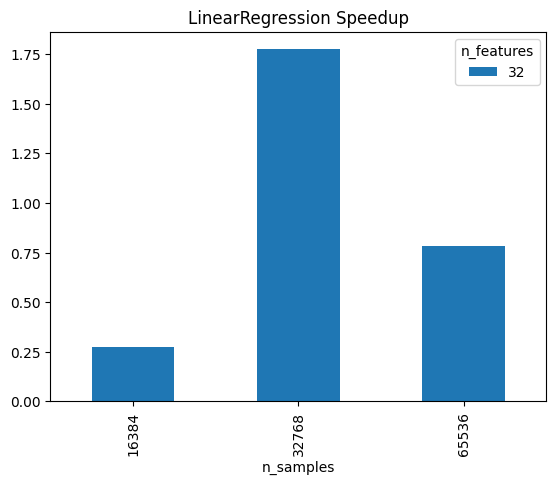

In [36]:
chart_single_algo_speedup(df, "LinearRegression")

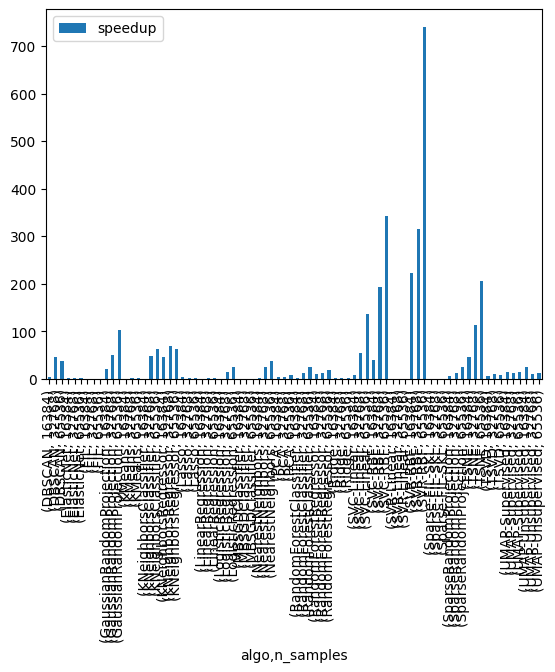

In [37]:
chart_all_algo_speedup(df)

### Output Results to CSV<a id="output_csv"/>

In [38]:
df.to_csv("benchmark_results.csv")